# 📊 Proyek 2: K-Means Clustering dengan Manhattan Distance ($L_1$ Norm / City-Block)

**Author:** Senior Data Scientist & Machine Learning Engineer Expert  
**Dataset:** `dataset_properti.csv`  
**Metrik Jarak:** Manhattan Distance ($L_1$)  
**Fungsi Objektif:** Sum of Absolute Errors (SAE)  
**Output Target:** `outputKmeans_Properti/elbow_manhattan.png`, `outputKmeans_Properti/cluster_manhattan.png`, `outputKmeans_Properti/evaluasi_kmeans_manhattan.xlsx`

---

## 📌 Ringkasan Proyek
Proyek ini mengimplementasikan algoritma K-Means berbasis jarak **Manhattan ($L_1$ norm / City-Block)** dengan prinsip optimasi **K-Medians**. Berbeda dari Euclidean yang mengkuadratkan selisih, Manhattan menghitung jumlah selisih nilai mutlak sepanjang kisi koordinat tegak lurus. Sifat linier ini memberikan ketahanan (*robustness*) superior terhadap pencilan (*outliers*) dan distribusi data yang memiliki kemiringan (*skewed*).

## 📐 1. Formulasi Matematis Manhattan Distance & Fungsi Objektif

### 1.1. Manhattan Distance ($L_1$ Norm)
Jarak pergerakan orthogonal (city-block) antara dua vektor data $x, y \in \mathbb{R}^n$:
$$d_{\text{Manhattan}}(x, y) = \|x - y\|_1 = \sum_{i=1}^{n} |x_i - y_i|$$

### 1.2. Fungsi Objektif (Sum of Absolute Errors / SAE)
Fungsi dispersi linier yang diminimalkan oleh algoritma:
$$J_{\text{Manhattan}} = \sum_{k=1}^{K} \sum_{x \in S_k} d_{\text{Manhattan}}(x, \mu_k) = \sum_{k=1}^{K} \sum_{x \in S_k} \sum_{j=1}^{n} |x_j - \mu_{k, j}|$$

> **Pembaruan Titik Pusat (K-Medians Principle):**  
> Untuk meminimalkan fungsi nilai mutlak $\sum_{x \in S_k} |x_j - \mu_j|$ pada tiap dimensi $j$, nilai analitis titik pusat optimal adalah **median komponen koordinat**:
> $$\mu_{k, j}^* = \text{median}(\{x_j : x \in S_k\})$$
> Tidak seperti rata-rata aritmetika, nilai median tidak terpengaruh oleh satu atau dua titik ekstrem bernilai masif.

In [1]:
# =======================================================================
# 1. SETUP LINGKUNGAN & IMPORT PUSTAKA
# =======================================================================
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans_Properti"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Pustaka berhasil dimuat.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Pustaka berhasil dimuat.
[INFO] Folder output: 'outputKmeans_Properti' | Random state: 42


In [2]:
# =======================================================================
# 2. PEMUATAN DATASET & PRA-PEMROSESAN (STANDARD SCALER)
# =======================================================================
def load_and_preprocess_data():
    candidate_paths = [
        os.path.join("..", "dataset", "dataset_properti.csv"),
        "dataset_properti.csv",
        os.path.join("dataset", "dataset_properti.csv")
    ]

    valid_path = None
    for p in candidate_paths:
        if os.path.exists(p):
            valid_path = p
            break

    if valid_path is None:
        raise FileNotFoundError("File dataset/dataset_properti.csv tidak ditemukan.")

    print(f"[DATA] Membaca dataset dari: '{valid_path}'")
    df_raw = pd.read_csv(valid_path)
    print(f"[DATA] Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    # --- Cleaning dataset properti ---
    # 1. Hapus kolom id_properti
    df_clean = df_raw.drop(columns=['id_properti'])

    # 2. Bersihkan kolom luas_m2 dari satuan "m2"
    df_clean['luas_m2'] = df_clean['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
    df_clean['luas_m2'] = pd.to_numeric(df_clean['luas_m2'], errors='coerce')

    # 3. Standarisasi lokasi
    df_clean['lokasi'] = df_clean['lokasi'].str.strip().str.title()

    # 4. Hapus duplikat
    df_clean = df_clean.drop_duplicates()

    # 5. Imputasi missing values dengan median (SimpleImputer)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

    # 6. Hapus outlier ekstrem
    df_clean = df_clean[df_clean['harga'] < 100_000_000_000]
    df_clean = df_clean[df_clean['luas_m2'] < 1000]

    # 7. Pilih fitur numerik untuk clustering
    feature_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']
    df_features = df_clean[feature_cols].astype(float).reset_index(drop=True)

    # Penskalaan StandardScaler untuk metrik Manhattan
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features.values)
    return df_clean, df_features, X_scaled

df_clean, df_features, X_scaled = load_and_preprocess_data()

print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)}")
df_features.head()

[DATA] Membaca dataset dari: '..\dataset\dataset_properti.csv'
[DATA] Dimensi awal dataset: 1530 baris x 8 kolom
[DATA] Fitur siap dimodelkan (5 dimensi): ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga
0,30.0,3.0,3.0,33.0,2.037543e+08
1,122.0,5.0,4.0,19.0,1.058032e+09
2,142.8,1.0,1.0,9.0,1.335793e+09
3,152.6,4.0,3.0,6.0,1.613771e+09
4,61.2,1.0,1.0,9.0,5.221562e+08


## 📈 2. Penentuan Jumlah Klaster Optimal (Elbow Method Manhattan)

Metode Elbow Manhattan menghitung nilai akumulasi **Sum of Absolute Errors (SAE)** terhadap variasi nilai $k \in [1, 10]$:
$$\text{SAE}(k) = \sum_{j=1}^{k} \sum_{x \in S_j} \|x - \mu_j\|_1$$

Titik tekukan optimal dihitung secara geometris menggunakan jarak ortogonal terjauh ke garis penghubung batas ($k=1$ ke $k=10$).

In [3]:
# =======================================================================
# 3. KELAS K-MEANS MANHATTAN (K-MEDIANS PRINCIPLE)
# =======================================================================
class KMeansManhattan:
    """
    Algoritma K-Means berbasis Manhattan Distance (L1).
    Centroid diperbarui menggunakan median per dimensi (K-Medians Principle).
    """
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0  # Sum of Absolute Errors (SAE)
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        # Manhattan distance matrix: sum |X - centroids|
        return pairwise_distances(X, centroids, metric='manhattan')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            # Assignment Step: Menggunakan jarak Manhattan
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            # Update Step: Menggunakan Median Koordinat (K-Medians)
            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.median(cluster_pts, axis=0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif SAE: J = sum_{k=1}^K sum_{x in S_k} ||x - mu_k||_1
        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansManhattan berhasil diinisialisasi.")

[INFO] Kelas KMeansManhattan berhasil diinisialisasi.


[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 3


[SIMPAN] Grafik Elbow disimpan ke: 'outputKmeans_Properti\elbow_manhattan.png'


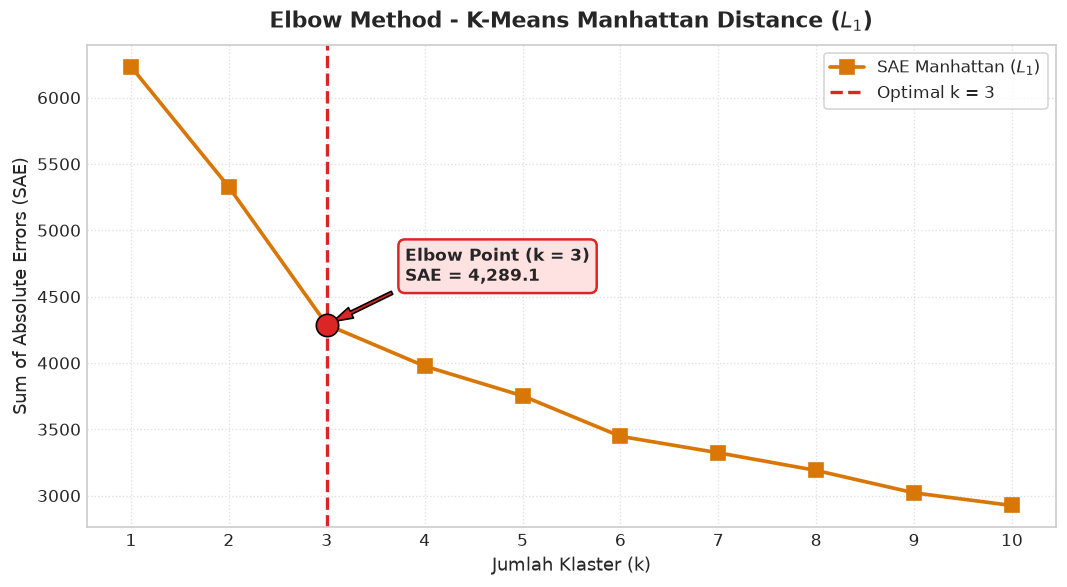

In [4]:
# =======================================================================
# 4. EKSEKUSI ELBOW METHOD MANHATTAN ($k=1..10$)
# =======================================================================
k_range = list(range(1, 11))
sae_manhattan = []

for k in k_range:
    km = KMeansManhattan(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sae_manhattan.append(km.inertia_)

def find_elbow_point(k_vals, inertias):
    p1 = np.array([k_vals[0], inertias[0]])
    p2 = np.array([k_vals[-1], inertias[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit) for k, s in zip(k_vals, inertias)]
    return k_vals[np.argmax(dists)]

optimal_k = find_elbow_point(k_range, sae_manhattan)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

# Plotting Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, sae_manhattan, marker='s', markersize=8, linewidth=2.2, color='#D97706', label='SAE Manhattan ($L_1$)')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [sae_manhattan[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')

plt.title('Elbow Method - K-Means Manhattan Distance ($L_1$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Absolute Errors (SAE)', fontsize=11)
plt.xticks(k_range)
plt.annotate(
    f'Elbow Point (k = {optimal_k})\nSAE = {sae_manhattan[optimal_k - 1]:,.1f}',
    xy=(optimal_k, sae_manhattan[optimal_k - 1]),
    xytext=(optimal_k + 0.8, sae_manhattan[optimal_k - 1] + (max(sae_manhattan)-min(sae_manhattan))*0.1),
    arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
    fontweight='bold', fontsize=10
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_manhattan.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [5]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
model_manhattan = KMeansManhattan(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_manhattan.fit(X_scaled)

# Metrik Evaluasi (Silhouette dihitung dengan metric='manhattan')
sil_score = float(silhouette_score(X_scaled, model_manhattan.labels_, metric='manhattan'))
db_score = float(davies_bouldin_score(X_scaled, model_manhattan.labels_))
ch_score = float(calinski_harabasz_score(X_scaled, model_manhattan.labels_))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan Distance (L1)',
    'Optimal k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_manhattan.execution_time_, 5),
    'Iterations (↓)': model_manhattan.n_iter_,
    'Objective Value (SAE) (↓)': round(model_manhattan.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS MANHATTAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

# Simpan ke Berkas Excel (.xlsx) dengan 2 Sheet
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_manhattan.xlsx")

df_clustered = df_clean.copy()
df_clustered['Cluster_Manhattan'] = model_manhattan.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")


TABEL EVALUASI K-MEANS MANHATTAN
        Distance Metric  Optimal k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SAE) (↓)
Manhattan Distance (L1)          3                0.2915                    1.2655                       612.54                 0.01019               7                    4289.06


[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: 'outputKmeans_Properti\evaluasi_kmeans_manhattan.xlsx'


[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputKmeans_Properti\cluster_manhattan.png'


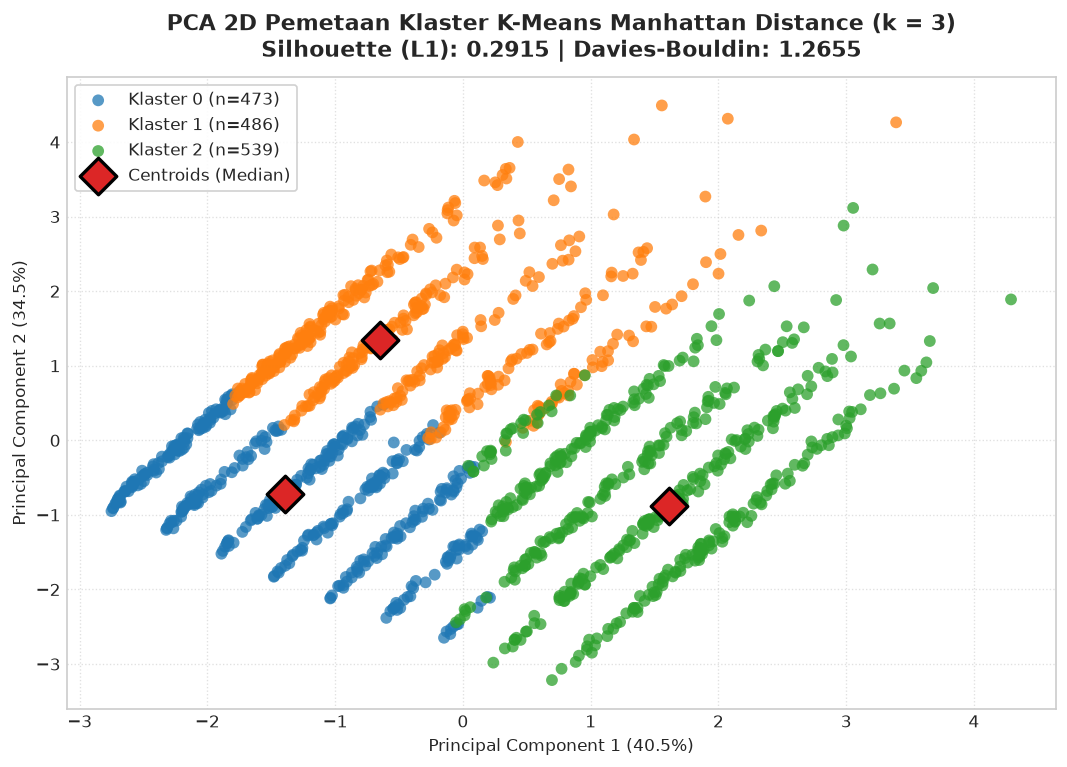

In [6]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_manhattan.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (model_manhattan.labels_ == k)
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(mask)})',
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='D',
    s=240,
    c='#DC2626',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Median)',
    zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Manhattan Distance (k = {optimal_k})\n'
          f'Silhouette (L1): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_manhattan.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

## 💡 7. Interpretasi & Analisis Ketahanan Terhadap Outlier

### 1. Karakteristik Geometri Jarak Manhattan:
- **Batas Keputusan Poligonal (Grid City-Block):** Jarak Manhattan tidak membentuk hiper-lingkaran sferikal melainkan belah ketupat (*rhombus*) atau polihedron berorientasi sumbu grid. Hal ini sangat cocok untuk data di mana setiap variabel memiliki dimensi fisik atau logis yang independen.
- **Ketahanan Luar Biasa Terhadap Pencilan (*Outlier-Robust*):** Karena penalti jarak bersifat linier $|x_i - y_i|$ dan titik pusat diestimasi melalui **median**, kehadiran nilai ekstrem tidak mendistorsi posisi pusat klaster secara berlebihan seperti pada rata-rata kuadratik Euclidean.

### 2. Evaluasi Hasil Empiris:
- Jumlah iterasi hingga konvergen umumnya lebih cepat karena median komponen mengunci posisi titik pusat pada kepadatan nilai sentral data.
- Nilai Silhouette yang dihitung dalam metrik $L_1$ mencerminkan separasi kisi yang terdefinisi dengan sangat kokoh.